<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/main/HierarchicalClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hierarchical Clustering

**Hierarchical Clustering** is an unsupervised machine learning algorithm that builds a tree-like hierarchy of clusters instead of partitioning data into a fixed number of groups from the start (like K-Means does).

This hierarchy is visually represented using a tree diagram called a **Dendrogram**, which allows data scientists to inspect the relationships between clusters and decide the optimal number of groups after the algorithm runs.

## The Two Main Types

Hierarchical clustering approaches the problem from two opposite directions:

1. **Agglomerative (Bottom-Up):**
   * Starts by treating every individual data point as a separate, single-element cluster ($N$ data points = $N$ clusters).
   * At each successive step, it merges the two closest clusters.
   * This repeats until all data points are fused into a single massive root cluster.
   * *This is the most common approach used in practice.*

2. **Divisive (Top-Down):**
   * Starts with all data points contained within a single large cluster.
   * It iteratively splits the cluster into smaller subgroups.
   * This continues until every individual point becomes its own independent cluster.

   ##Dendrogram
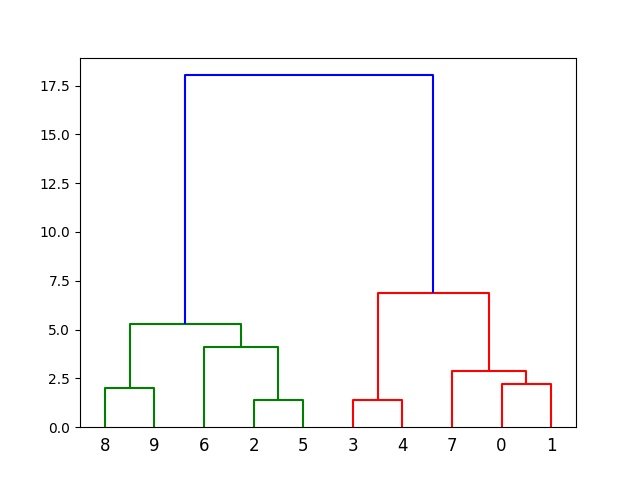

## Linkage Methods (Measuring Cluster Distance)

To merge or split clusters, the algorithm needs to calculate the distance between groups of points, not just individual dots. This is governed by **Linkage Criteria**:

* **Single Linkage:** Measures the minimum distance between any single point in Cluster A and any single point in Cluster B. (Prone to trailing "chaining" effects).
  $$d(A, B) = \min \{ \text{dist}(x, y) : x \in A, y \in B \}$$

* **Complete Linkage:** Measures the maximum distance between any single point in Cluster A and any single point in Cluster B. (Produces compact, spherical clusters).
  $$d(A, B) = \max \{ \text{dist}(x, y) : x \in A, y \in B \}$$

* **Average Linkage:** Measures the average distance between every possible pair of points across the two clusters.
  $$d(A, B) = \frac{1}{|A| \cdot |B|} \sum_{x \in A} \sum_{y \in B} \text{dist}(x, y)$$

* **Ward's Linkage:** Minimizes the total Within-Cluster Sum of Squares (WCSS) variance caused by merging two clusters. It acts similarly to K-Means optimization and is often the default choice.

## How to Find the Optimal Number of Clusters Using a Dendrogram

The **Dendrogram** maps out the history of every single merge that occurred during the algorithm's execution:
* The **X-axis** lists the individual data samples.
* The **Y-axis** represents the distance or dissimilarity threshold at which clusters were merged.

### The Maximum Vertical Distance Rule
To find the ideal number of clusters from a dendrogram:
1. Look for the longest, tallest vertical lines in the diagram that are not intercepted by any horizontal splitting branch.
2. Draw a horizontal imaginary "cut line" directly through these long vertical sections.
3. Count how many vertical lines your horizontal cut passes through. That count is your optimal number of clusters ($K$).

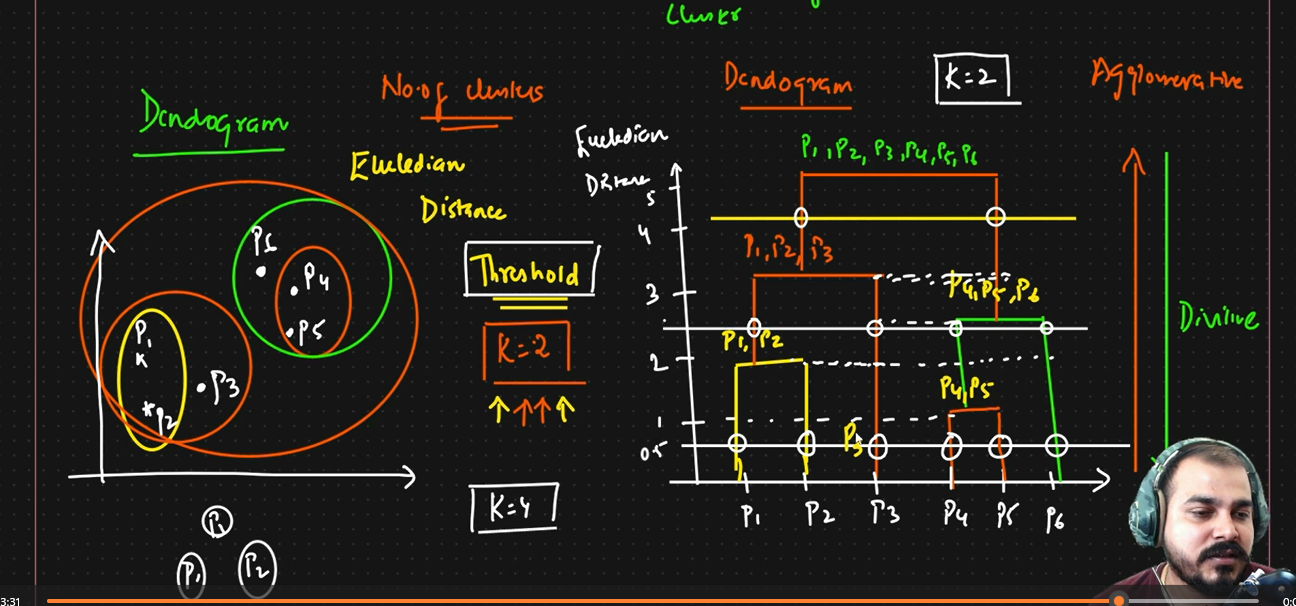

## Pros and Cons of Hierarchical Clustering

### Advantages
* **No Predefined $K$:** You do not need to guess or hardcode the number of clusters before running the model.
* **Intuitive Visualization:** The dendrogram makes it simple to understand nested relationships within data.
* **Flexible Linkage:** Can adapt to different structural geometries by modifying the linkage method.

### Disadvantages
* **Computationally Expensive:** The algorithm has a time complexity of $O(N^3)$ and space complexity of $O(N^2)$. It becomes extremely slow and memory-intensive on large datasets.
* **No Reversible Steps:** Once two clusters are merged at a lower step, the algorithm cannot undo that decision later on.



# ***Impelemenet Hierarchial Clustaring***

In [26]:
#Baisc liberis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
#Import dataset as iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
#Standarized the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled


array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [29]:
#Apply PCA for converting 3 dimension to 2 dimension
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

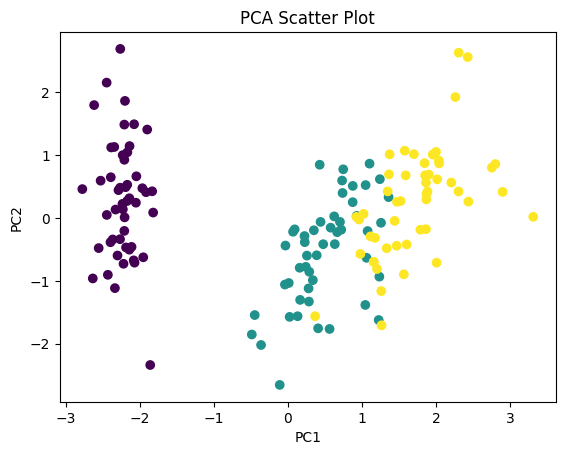

In [30]:
#Plt the point into the scatter
plt.scatter(df_pca[:,0], df_pca[:,1],c=iris.target)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')
plt.show()

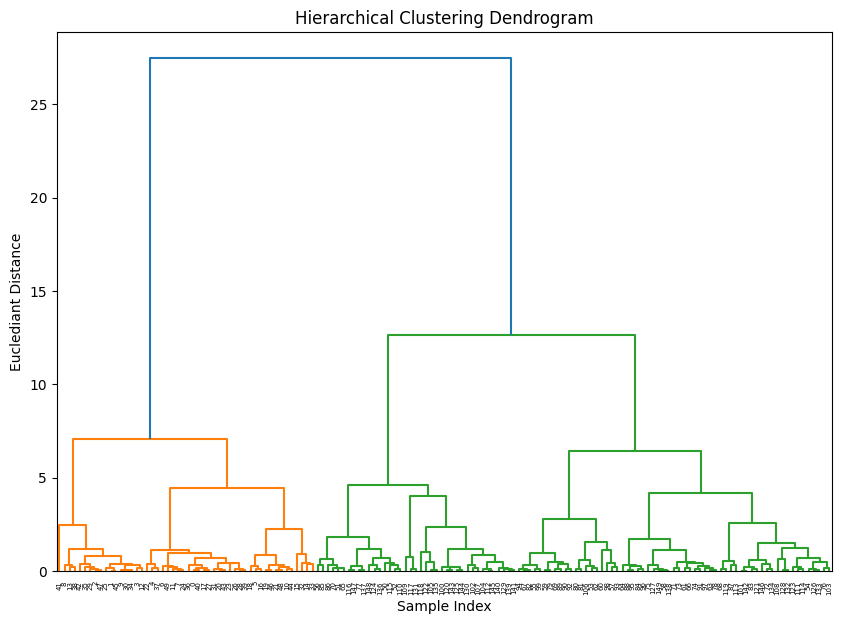

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
#Plot the dendoram
plt.figure(figsize=(10,7))
# Perform hierarchical clustering (linkage)
linked = linkage(df_pca, method='ward') # 'ward' is a common linkage method
# Plot the dendrogram
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Euclediant Distance')
plt.show()

In [32]:
#Applysing agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
agg_model.fit(df_pca)

AgglomerativeClustering()

In [33]:
agg_model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

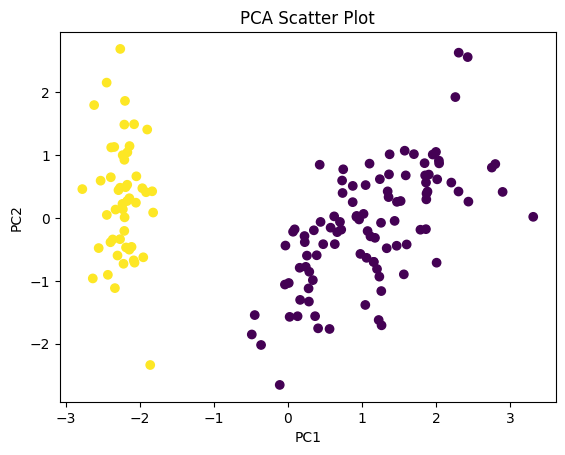

In [34]:
plt.scatter(df_pca[:,0], df_pca[:,1],c=agg_model.labels_)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')
plt.show()